# Diabetes Prediction using Machine Learning

## Problem Statement

Diabetes is one of the most common chronic diseases worldwide. Early prediction can help healthcare professionals identify high-risk patients and provide timely treatment.

The objective of this project is to develop a supervised machine learning model that predicts whether a patient is diabetic or non-diabetic based on demographic and medical attributes such as age, gender, BMI, HbA1c level, blood glucose level, hypertension, heart disease, and smoking history.


## Import Required Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Display all columns
pd.set_option("display.max_columns", None)

# Better graph style
sns.set_style("whitegrid")

## Load the Dataset

In [2]:
df = pd.read_csv("diabetes_prediction_dataset.csv")

In [3]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [4]:
df.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


In [5]:
df.shape

(100000, 9)

In [6]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [8]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


## Observation

- The dataset contains demographic and medical information of patients.
- Both numerical and categorical features are present.
- The target variable is **diabetes**, making this a **binary classification** problem.

## Data Preprocessing
In this section, we check for missing values, duplicate records, unique values, and prepare the dataset for machine learning.

In [9]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [10]:
df.duplicated().sum()

np.int64(3854)

In [11]:
df = df.drop_duplicates()

In [12]:
df.shape

(96146, 9)

In [13]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("-"*50)

gender
['Female' 'Male' 'Other']
--------------------------------------------------
age
[80.   54.   28.   36.   76.   20.   44.   79.   42.   32.   53.   78.
 67.   15.   37.   40.    5.   69.   72.    4.   30.   45.   43.   50.
 41.   26.   34.   73.   77.   66.   29.   60.   38.    3.   57.   74.
 19.   46.   21.   59.   27.   13.   56.    2.    7.   11.    6.   55.
  9.   62.   47.   12.   68.   75.   22.   58.   18.   24.   17.   25.
  0.08 33.   16.   61.   31.    8.   49.   39.   65.   14.   70.    0.56
 48.   51.   71.    0.88 64.   63.   52.    0.16 10.   35.   23.    0.64
  1.16  1.64  0.72  1.88  1.32  0.8   1.24  1.    1.8   0.48  1.56  1.08
  0.24  1.4   0.4   0.32  1.72  1.48]
--------------------------------------------------
hypertension
[0 1]
--------------------------------------------------
heart_disease
[1 0]
--------------------------------------------------
smoking_history
['never' 'No Info' 'current' 'former' 'ever' 'not current']
--------------------------------

In [14]:
df["diabetes"].value_counts()

,count
diabetes,
0,87664
1,8482


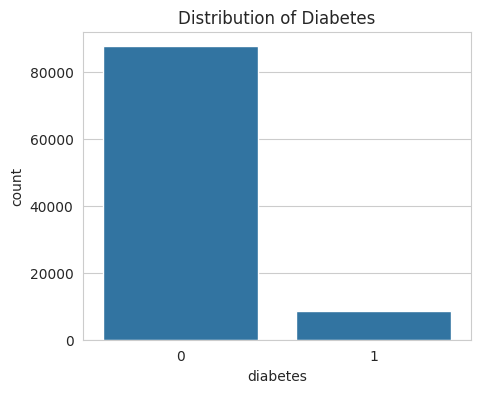

In [15]:
plt.figure(figsize=(5,4))

sns.countplot(x="diabetes", data=df)

plt.title("Distribution of Diabetes")
plt.show()

In [16]:
df = df.drop_duplicates()

df.shape

df["diabetes"].value_counts()

,count
diabetes,
0,87664
1,8482


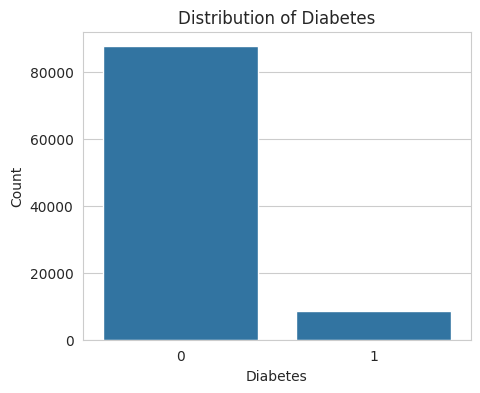

In [17]:
plt.figure(figsize=(5,4))
sns.countplot(x="diabetes", data=df)

plt.title("Distribution of Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("Count")

plt.show()

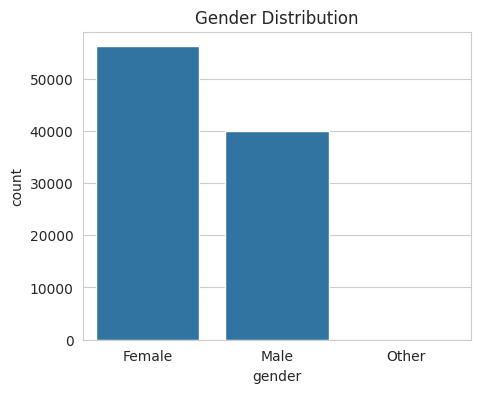

In [18]:
plt.figure(figsize=(5,4))
sns.countplot(x="gender", data=df)

plt.title("Gender Distribution")

plt.show()

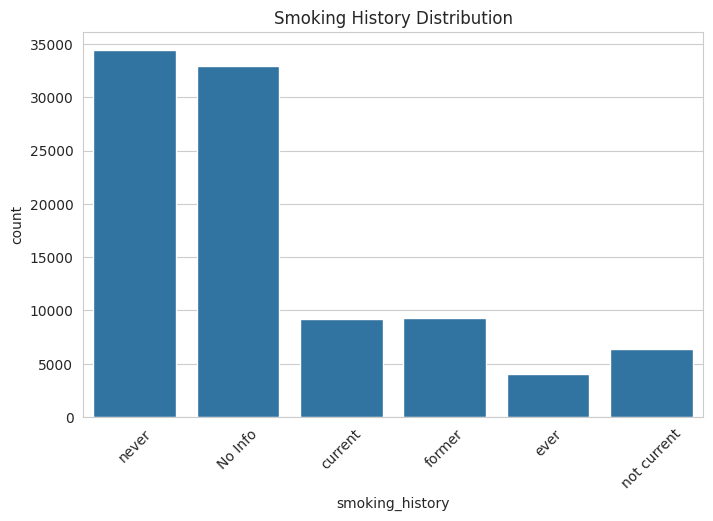

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(x="smoking_history", data=df)

plt.xticks(rotation=45)

plt.title("Smoking History Distribution")

plt.show()

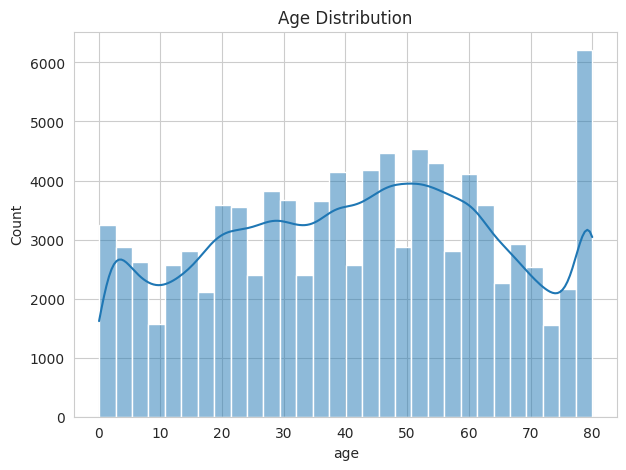

In [20]:
plt.figure(figsize=(7,5))

sns.histplot(df["age"], bins=30, kde=True)

plt.title("Age Distribution")

plt.show()

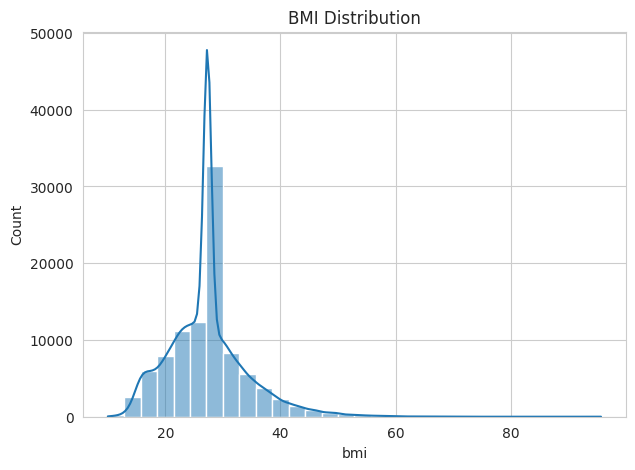

In [21]:
plt.figure(figsize=(7,5))

sns.histplot(df["bmi"], bins=30, kde=True)

plt.title("BMI Distribution")

plt.show()

# Feature Encoding

Machine learning algorithms cannot directly process categorical (text) values. Therefore, categorical features are converted into numerical format using encoding techniques.

In [22]:
df.select_dtypes(include="object").columns

Index(['gender', 'smoking_history'], dtype='object')

In [23]:
df["gender"].value_counts()

,count
gender,
Female,56161
Male,39967
Other,18


In [24]:
df["smoking_history"].value_counts()

,count
smoking_history,
never,34398
No Info,32887
former,9299
current,9197
not current,6367
ever,3998


In [25]:
df = pd.get_dummies(
    df,
    columns=["gender", "smoking_history"],
    drop_first=True
)

In [26]:
df.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,False,False,False,False,False,True,False
1,54.0,0,0,27.32,6.6,80,0,False,False,False,False,False,False,False
2,28.0,0,0,27.32,5.7,158,0,True,False,False,False,False,True,False
3,36.0,0,0,23.45,5.0,155,0,False,False,True,False,False,False,False
4,76.0,1,1,20.14,4.8,155,0,True,False,True,False,False,False,False


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96146 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          96146 non-null  float64
 1   hypertension                 96146 non-null  int64  
 2   heart_disease                96146 non-null  int64  
 3   bmi                          96146 non-null  float64
 4   HbA1c_level                  96146 non-null  float64
 5   blood_glucose_level          96146 non-null  int64  
 6   diabetes                     96146 non-null  int64  
 7   gender_Male                  96146 non-null  bool   
 8   gender_Other                 96146 non-null  bool   
 9   smoking_history_current      96146 non-null  bool   
 10  smoking_history_ever         96146 non-null  bool   
 11  smoking_history_former       96146 non-null  bool   
 12  smoking_history_never        96146 non-null  bool   
 13  smoking_history_not c

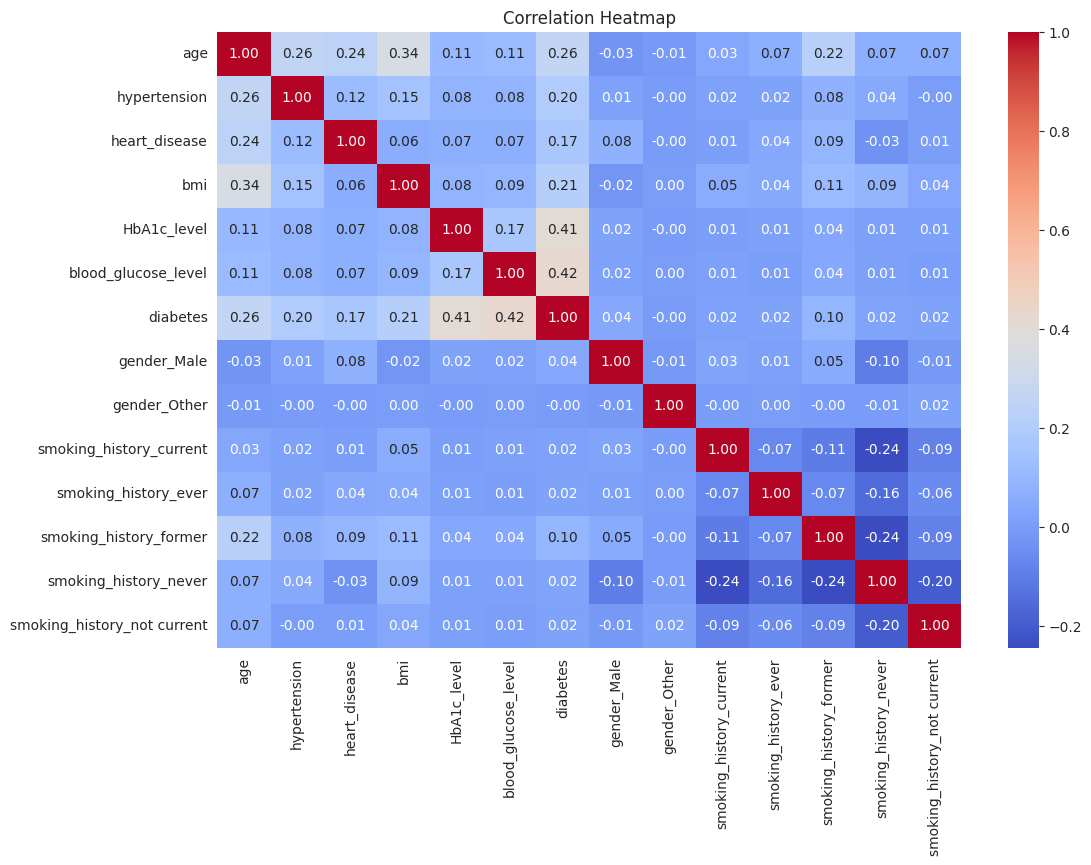

In [28]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

# Feature Selection

The input features are stored in X, while the target variable (diabetes) is stored in y.

In [29]:
# Features
X = df.drop("diabetes", axis=1)

# Target
y = df["diabetes"]

In [30]:
print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (96146, 13)
y Shape : (96146,)


# Train-Test Split

The dataset is divided into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate its performance.

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (76916, 13)
X_test : (19230, 13)
y_train : (76916,)
y_test : (19230,)


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Logistic Regression Model

Logistic Regression is one of the most commonly used supervised machine learning algorithms for binary classification problems.

In [36]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42)

log_model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [37]:
y_pred = log_model.predict(X_test)

In [38]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9570982839313572


In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98     17509
           1       0.85      0.63      0.72      1721

    accuracy                           0.96     19230
   macro avg       0.91      0.81      0.85     19230
weighted avg       0.95      0.96      0.95     19230



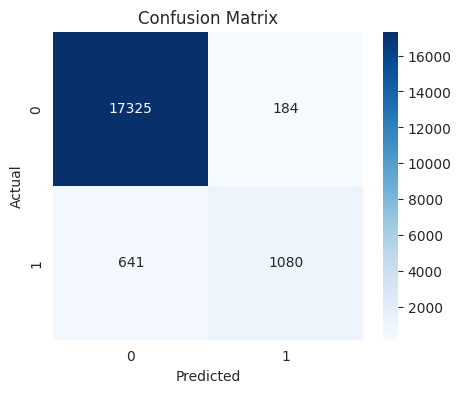

In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [41]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9570982839313572
Precision : 0.8544303797468354
Recall : 0.6275421266705404
F1 Score : 0.7236180904522613


# Save Trained Model

The trained Logistic Regression model is saved using Python's Pickle library so that it can be loaded later without retraining.

In [42]:
import pickle

# Save trained model
with open("diabetes_model.pkl", "wb") as file:
    pickle.dump(log_model, file)

print("Model saved successfully!")

Model saved successfully!


In [43]:
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Scaler saved successfully!")

Scaler saved successfully!


In [44]:
loaded_model = pickle.load(open("diabetes_model.pkl", "rb"))

prediction = loaded_model.predict(X_test)

print(prediction[:10])

[0 0 1 0 0 0 0 0 0 0]


# Conclusion

In this project, a Logistic Regression model was developed to predict whether a patient has diabetes based on demographic and medical information.

The dataset was preprocessed by removing duplicate records, encoding categorical variables, and scaling numerical features. Exploratory Data Analysis (EDA) was performed to understand the data distribution and relationships among variables.

The trained Logistic Regression model achieved:

- Accuracy: **95.71%**
- Precision: **85.44%**
- Recall: **62.75%**
- F1 Score: **72.36%**

The results indicate that the model performs well in identifying diabetic and non-diabetic patients and can serve as a useful baseline model for diabetes prediction.